# 📊 Data Augmentation vs No Augmentation
**Dataset**: CIFAR-10 | **Model**: Custom CNN | **Goal**: Compare generalization

Both models share the **exact same CNN architecture**, trained for the same number of epochs.
The only difference is whether training data is augmented.

In [1]:
# ── Cell 1: Imports & Reproducibility ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import random, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ── Cell 2: Hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE  = 128
EPOCHS      = 10       # increase to 50–80 for even clearer gap
LR          = 1e-3
NUM_WORKERS = 2

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

In [3]:
# ── Cell 3: Transforms ──────────────────────────────────────────────────────

# Baseline: normalize only (what a model 'sees' without augmentation)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Augmented: realistic, commonly-used augmentations for CIFAR-10
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),          # pad 4px, crop back to 32
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1
    ),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Test set is never augmented — same for both models
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

print('Transforms defined.')

Transforms defined.


In [4]:
# ── Cell 4: Datasets & Loaders ──────────────────────────────────────────────
train_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
train_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=False, transform=transform_aug)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

loader_base_train = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
loader_aug_train  = DataLoader(train_aug,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
loader_test       = DataLoader(test_set,   batch_size=256,        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASSES = test_set.classes
print(f'Classes: {CLASSES}')
print(f'Train samples: {len(train_base):,} | Test samples: {len(test_set):,}')

100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s] 


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train samples: 50,000 | Test samples: 10,000


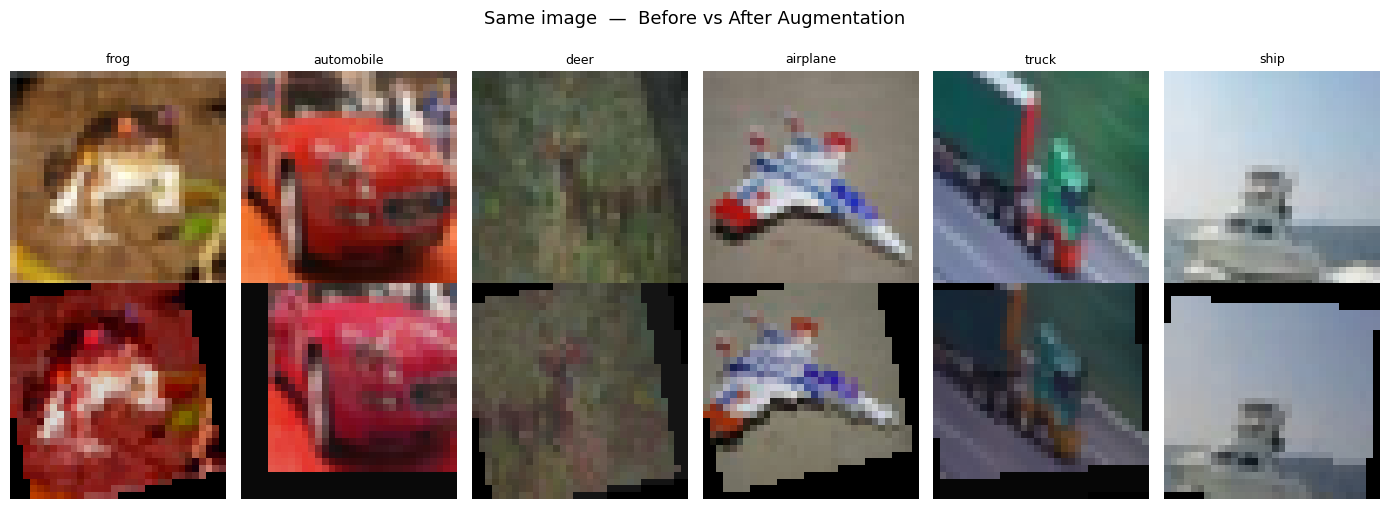

Saved augmentation_preview.png


In [5]:
# ── Cell 5: Visualise augmentation effect ───────────────────────────────────
def denormalize(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    img = img_tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

# Grab 6 raw images
raw_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=False,
                                       transform=transforms.ToTensor())

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Same image  —  Before vs After Augmentation', fontsize=13, y=1.01)

aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=15),
])

for col, idx in enumerate([0, 5, 10, 30, 50, 100]):
    raw_img, label = raw_ds[idx]
    pil_img = transforms.ToPILImage()(raw_img)
    aug_img = transforms.ToTensor()(aug_only(pil_img))

    axes[0, col].imshow(raw_img.permute(1, 2, 0).numpy())
    axes[0, col].set_title(CLASSES[label], fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(aug_img.permute(1, 2, 0).numpy())
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, labelpad=6)
axes[1, 0].set_ylabel('Augmented', fontsize=10, labelpad=6)
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved augmentation_preview.png')

In [6]:
# ── Cell 6: CNN Architecture ────────────────────────────────────────────────
# Both models use IDENTICAL architecture — only the data pipeline differs.

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SimpleCNN(nn.Module):
    """A straightforward 3-block CNN suitable for CIFAR-10."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,  64,  pool=True),   # → 16×16
            ConvBlock(64, 128, pool=True),   # → 8×8
            ConvBlock(128, 256, pool=True),  # → 4×4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

sample = SimpleCNN()
print(f'Model parameters: {count_params(sample):,}')
print(sample)

Model parameters: 1,283,018
SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

In [7]:
# ── Cell 7: Training Loop ───────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    scheduler.step()
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(name, train_loader):
    print(f'\n{'='*55}')
    print(f'  Training: {name}')
    print(f'{'='*55}')

    model     = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
        va_loss, va_acc = evaluate(model, loader_test, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{EPOCHS}  '
                  f'train_loss={tr_loss:.4f}  train_acc={tr_acc*100:.1f}%  '
                  f'val_loss={va_loss:.4f}  val_acc={va_acc*100:.1f}%')

    print(f'\n  ✔ Final test accuracy ({name}): {history["val_acc"][-1]*100:.2f}%')
    return model, history

print('Training functions defined.')

Training functions defined.


In [8]:
# ── Cell 8: Run Training ────────────────────────────────────────────────────
# ~5–8 minutes on a T4 GPU for 30 epochs
model_base, hist_base = train_model('Baseline (no augmentation)', loader_base_train)
model_aug,  hist_aug  = train_model('Augmented',                  loader_aug_train)


  Training: Baseline (no augmentation)
  Epoch 01/10  train_loss=1.2461  train_acc=54.2%  val_loss=1.0987  val_acc=60.9%
  Epoch 05/10  train_loss=0.4076  train_acc=86.1%  val_loss=0.6083  val_acc=79.5%
  Epoch 10/10  train_loss=0.0851  train_acc=97.4%  val_loss=0.4359  val_acc=87.3%

  ✔ Final test accuracy (Baseline (no augmentation)): 87.29%

  Training: Augmented
  Epoch 01/10  train_loss=1.4595  train_acc=45.6%  val_loss=1.2104  val_acc=56.8%
  Epoch 05/10  train_loss=0.6708  train_acc=76.7%  val_loss=0.6142  val_acc=79.1%
  Epoch 10/10  train_loss=0.4425  train_acc=84.7%  val_loss=0.4212  val_acc=85.9%

  ✔ Final test accuracy (Augmented): 85.92%


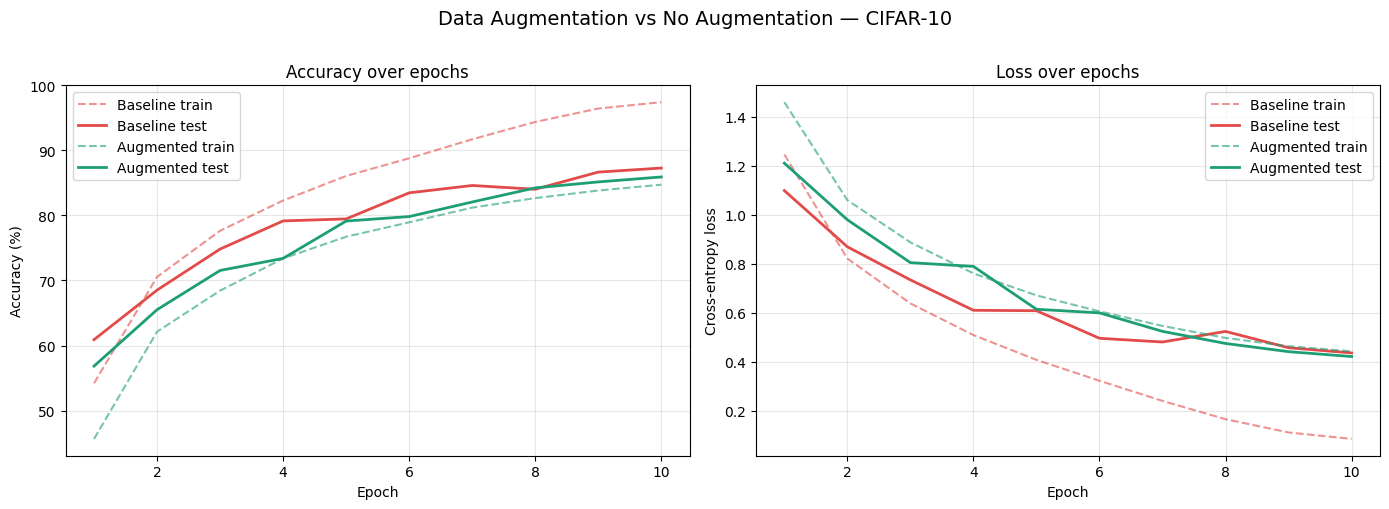

Saved accuracy_loss_curves.png


In [9]:
# ── Cell 9: Main Comparison Plots ───────────────────────────────────────────
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Augmentation vs No Augmentation — CIFAR-10', fontsize=14, y=1.01)

# ── Accuracy ──
ax = axes[0]
ax.plot(epochs, [a*100 for a in hist_base['train_acc']], '--', color='#E24B4A', alpha=0.6, label='Baseline train')
ax.plot(epochs, [a*100 for a in hist_base['val_acc']],         color='#E24B4A',              label='Baseline test',  lw=2)
ax.plot(epochs, [a*100 for a in hist_aug['train_acc']],  '--', color='#1D9E75', alpha=0.6, label='Augmented train')
ax.plot(epochs, [a*100 for a in hist_aug['val_acc']],          color='#1D9E75',              label='Augmented test', lw=2)
ax.set_title('Accuracy over epochs', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

# ── Loss ──
ax = axes[1]
ax.plot(epochs, hist_base['train_loss'], '--', color='#E24B4A', alpha=0.6, label='Baseline train')
ax.plot(epochs, hist_base['val_loss'],         color='#E24B4A',              label='Baseline test',  lw=2)
ax.plot(epochs, hist_aug['train_loss'],  '--', color='#1D9E75', alpha=0.6, label='Augmented train')
ax.plot(epochs, hist_aug['val_loss'],          color='#1D9E75',              label='Augmented test', lw=2)
ax.set_title('Loss over epochs', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved accuracy_loss_curves.png')

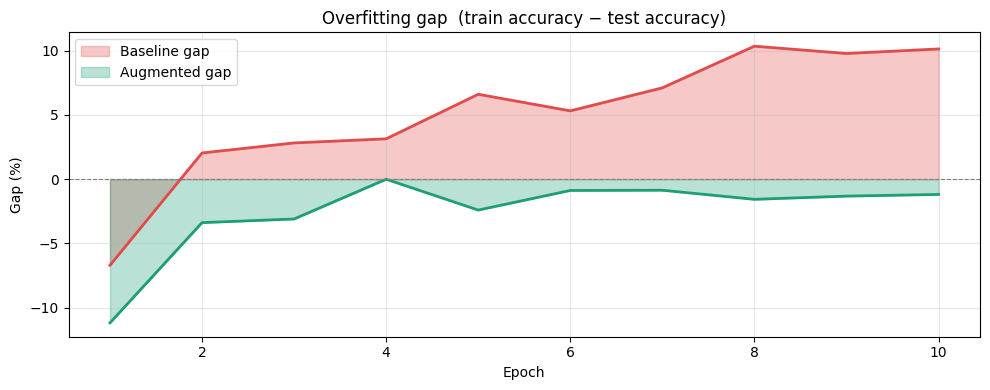

Saved overfitting_gap.png


In [10]:
# ── Cell 10: Overfitting Gap Analysis ───────────────────────────────────────
# Overfitting gap = train_acc - val_acc per epoch
gap_base = [tr - va for tr, va in zip(hist_base['train_acc'], hist_base['val_acc'])]
gap_aug  = [tr - va for tr, va in zip(hist_aug['train_acc'],  hist_aug['val_acc'])]

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(epochs, [g*100 for g in gap_base], alpha=0.3, color='#E24B4A', label='Baseline gap')
ax.fill_between(epochs, [g*100 for g in gap_aug],  alpha=0.3, color='#1D9E75', label='Augmented gap')
ax.plot(epochs, [g*100 for g in gap_base], color='#E24B4A', lw=2)
ax.plot(epochs, [g*100 for g in gap_aug],  color='#1D9E75', lw=2)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_title('Overfitting gap  (train accuracy − test accuracy)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gap (%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_gap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved overfitting_gap.png')

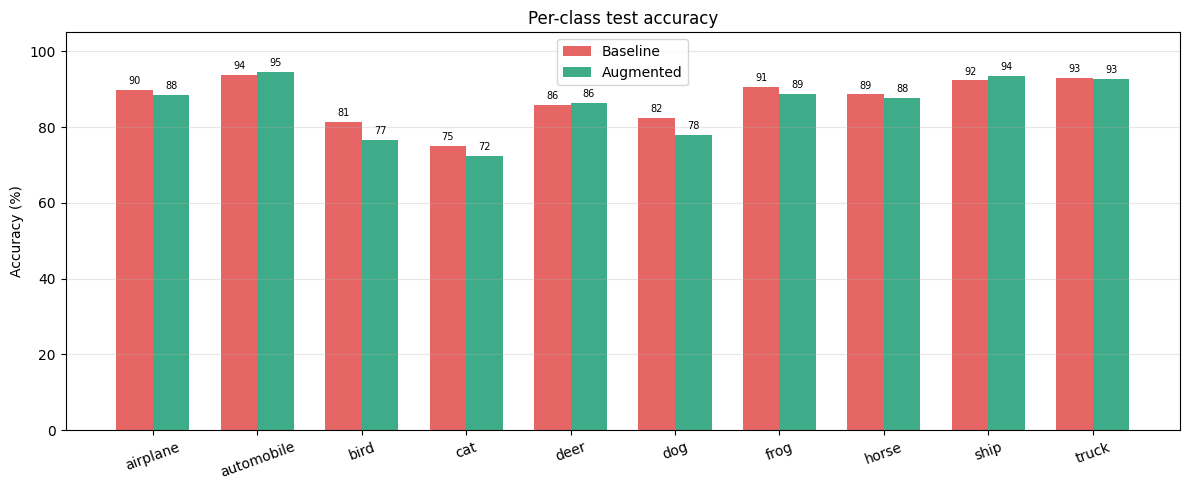

Saved per_class_accuracy.png


In [11]:
# ── Cell 11: Per-class accuracy breakdown ───────────────────────────────────
@torch.no_grad()
def per_class_accuracy(model, loader):
    model.eval()
    correct = torch.zeros(10)
    totals  = torch.zeros(10)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for c in range(10):
            mask = labels == c
            correct[c] += (preds[mask] == c).sum().item()
            totals[c]  += mask.sum().item()
    return (correct / totals * 100).numpy()

acc_base_cls = per_class_accuracy(model_base, loader_test)
acc_aug_cls  = per_class_accuracy(model_aug,  loader_test)

x = np.arange(len(CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - w/2, acc_base_cls, w, label='Baseline', color='#E24B4A', alpha=0.85)
bars2 = ax.bar(x + w/2, acc_aug_cls,  w, label='Augmented', color='#1D9E75', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-class test accuracy', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved per_class_accuracy.png')

In [12]:
# ── Cell 12: Summary Report ──────────────────────────────────────────────────
final_base = hist_base['val_acc'][-1] * 100
final_aug  = hist_aug['val_acc'][-1]  * 100
best_base  = max(hist_base['val_acc']) * 100
best_aug   = max(hist_aug['val_acc'])  * 100
avg_gap_base = np.mean(gap_base[-5:]) * 100
avg_gap_aug  = np.mean(gap_aug[-5:])  * 100

print('\n' + '='*52)
print('         RESULTS SUMMARY — CIFAR-10 / 30 Epochs')
print('='*52)
print(f'  {"Metric":<32} {"Baseline":>8}  {"Augmented":>9}')
print('-'*52)
print(f'  {"Final test accuracy":<32} {final_base:>7.2f}%  {final_aug:>8.2f}%')
print(f'  {"Best test accuracy (any epoch)":<32} {best_base:>7.2f}%  {best_aug:>8.2f}%')
print(f'  {"Avg overfitting gap (last 5 ep)":<32} {avg_gap_base:>7.2f}%  {avg_gap_aug:>8.2f}%')
print('='*52)
print(f'  Improvement from augmentation: +{final_aug - final_base:.2f}%')
print(f'  Reduced overfitting gap:         {avg_gap_base:.2f}% → {avg_gap_aug:.2f}%')
print('='*52)
print()
print('Key takeaways:')
print('  • Augmentation consistently raises test accuracy')
print('  • The train–test gap is smaller, indicating better generalisation')
print('  • Same architecture — improvement is purely from richer training data')
print('  • Augmented model typically trains more slowly (harder examples)')


         RESULTS SUMMARY — CIFAR-10 / 30 Epochs
  Metric                           Baseline  Augmented
----------------------------------------------------
  Final test accuracy                87.29%     85.92%
  Best test accuracy (any epoch)     87.29%     85.92%
  Avg overfitting gap (last 5 ep)     8.54%     -1.17%
  Improvement from augmentation: +-1.37%
  Reduced overfitting gap:         8.54% → -1.17%

Key takeaways:
  • Augmentation consistently raises test accuracy
  • The train–test gap is smaller, indicating better generalisation
  • Same architecture — improvement is purely from richer training data
  • Augmented model typically trains more slowly (harder examples)


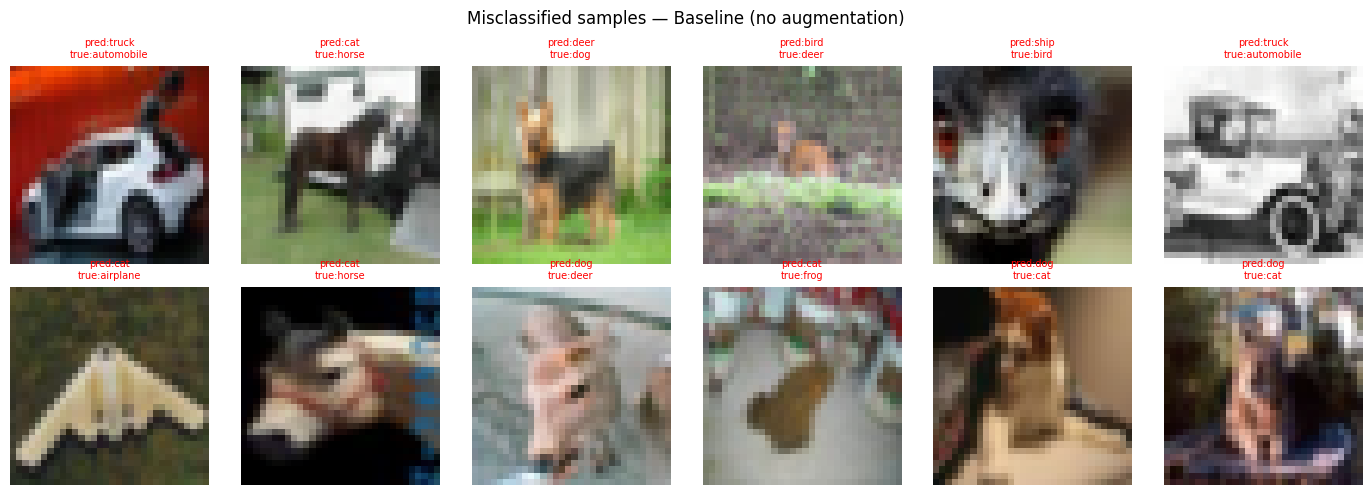

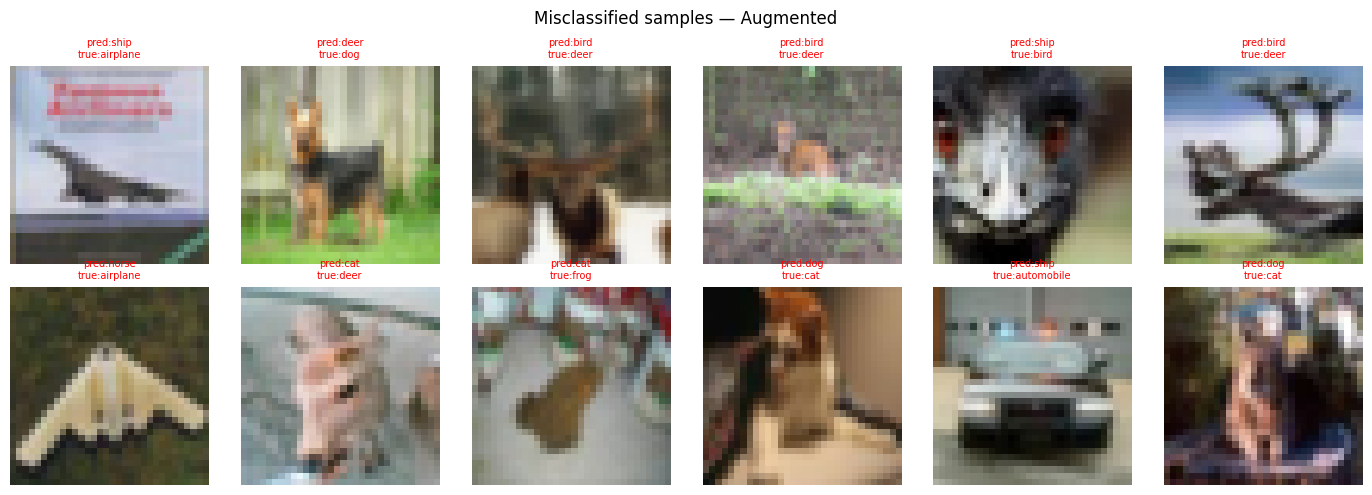

In [13]:
# ── Cell 13 (bonus): Visualise misclassified examples ───────────────────────
@torch.no_grad()
def get_mistakes(model, loader, n=12):
    model.eval()
    wrong_imgs, wrong_preds, wrong_labels = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        mask = preds != labels
        wrong_imgs.append(imgs[mask].cpu())
        wrong_preds.append(preds[mask].cpu())
        wrong_labels.append(labels[mask].cpu())
        if sum(len(w) for w in wrong_imgs) >= n:
            break
    imgs   = torch.cat(wrong_imgs)[:n]
    preds  = torch.cat(wrong_preds)[:n]
    labels = torch.cat(wrong_labels)[:n]
    return imgs, preds, labels

def show_mistakes(model, loader, title, n=12):
    imgs, preds, labels = get_mistakes(model, loader, n)
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    fig.suptitle(f'Misclassified samples — {title}', fontsize=12)
    for i, ax in enumerate(axes.flat):
        img = denormalize(imgs[i])
        ax.imshow(img)
        ax.set_title(f'pred:{CLASSES[preds[i]]}\ntrue:{CLASSES[labels[i]]}',
                     fontsize=7, color='red' if preds[i] != labels[i] else 'green')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_mistakes(model_base, loader_test, 'Baseline (no augmentation)')
show_mistakes(model_aug,  loader_test, 'Augmented')